In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm


import pandas as pd
from src.processing import find_pareto_front
from src.visualization import display_pareto_front, display_two_pareto_fronts, display_pareto_fronts3, display_fitness_landscape_with_2pareto
from src.metrics import calculate_gamma_convergence_metric, print_gamma_metric

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Parâmetros NSGA-II
config = {
    # definindo o algoritmo
    'population_size': 2000,
    'n_generations': 200,
    'k_tournament': 2,
    'crossover_prob': 0.9,
    'crossover_eta': 15,
    'mutation_prob': 1/6,  # 1/n_var
    'mutation_eta': 20,
    'seed': 42,
    'track_progress': True,

    # definindo o problema
    'n_objetivos': 2,
    'fitness_cols': ["fitness1", "fitness2"],
    'maximize': True,
    'n_restricoes': 0,

    # definindo o genótipo
    'tamanho_genotipo': 6,
    'limite_inferior': np.array([0, 0, 0, 0, 0, 0]),
    'limite_superior': np.array([9, 9, 9, 9, 9, 9]),
    'tipo_variavel_genotipo': int
}

In [3]:
df1 = pd.read_parquet('data/df_surrogate1.parquet')
df2 = pd.read_parquet('data/df_surrogate2.parquet')

print(df1.shape)
print(df2.shape)
display(df2.head())

(1000000, 45)
(1000000, 49)


,registro,fitness1_eq0,fitness1_eq1,fitness1_eq2,fitness1_eq3,fitness1_eq4,fitness1_eq5,fitness1_eq6,fitness1_eq7,fitness1_eq8,...,erro_abs1_c3,fitness2_c1,fitness2_c2,fitness2_c3,erro2_c1,erro_abs2_c1,erro2_c2,erro_abs2_c2,erro2_c3,erro_abs2_c3
0,0,0.000000e+00,10.0,7.0,4.0,5.0,5.0,0.0000,3.000000,2.000000,...,3.402582,11.550515,11.242739,12.287389,-2.064098,2.064098,-1.756321,1.756321,-2.800971,2.800971
1,1,5.714286e-12,10.0,7.0,4.0,5.0,5.0,0.0004,3.000000,1.999998,...,3.249206,11.550515,11.242739,12.287389,-2.065560,2.065560,-1.757783,1.757783,-2.802434,2.802434
2,2,2.285714e-11,10.0,7.0,4.0,5.0,5.0,0.0008,2.999999,1.999994,...,3.250980,11.550515,11.242739,12.287389,-2.067021,2.067021,-1.759245,1.759245,-2.803895,2.803895
3,3,5.142857e-11,10.0,7.0,4.0,5.0,5.0,0.0012,2.999998,1.999986,...,3.252751,11.550515,11.242739,11.944605,-2.068481,2.068481,-1.760704,1.760704,-2.462571,2.462571
4,4,9.142857e-11,10.0,7.0,4.0,5.0,5.0,0.0016,2.999996,1.999975,...,3.254520,11.550515,11.242739,11.944605,-2.069939,2.069939,-1.762163,1.762163,-2.464029,2.464029


In [4]:
df_mcmc1 = pd.read_parquet('data/df_mcmc1.parquet').rename(columns={'index_linha': 'id_simulacao'})
df_mcmc2 = pd.read_parquet('data/df_mcmc2.parquet').rename(columns={'index_linha': 'id_simulacao'})

df_mcmc1.sort_values(['regiao', 'id_simulacao'], inplace=True)
df_mcmc2.sort_values(['regiao', 'id_simulacao'], inplace=True)

config['n_simulations'] = df_mcmc2['id_simulacao'].max() + 1
print('n_simulations: ', config['n_simulations'])

print(df_mcmc1.shape)
print(df_mcmc2.shape)
display(df_mcmc2.head())

n_simulations:  10
(50, 4)
(50, 4)


,id_simulacao,regiao,erro1_c1,erro2_c1
0,0,1,0.441198,-3.528011
1,1,1,2.860782,1.527073
2,2,1,2.758490,-0.195303
3,3,1,-0.355703,-3.481056
4,4,1,3.966358,1.404615


# Problema 1

In [5]:
from src.nsgaII import run_my_nsga2
from src.ua_sa_nsgaII import run_my_uasa_nsga2

In [6]:
cols_landscape = ['registro', 'id_simulacao', 'fitness1', 'fitness2']
cols_df = ['registro', 'regiao', 'fitness1_c1', 'fitness2_c1']

df_landscape1 = df1[cols_df].merge(df_mcmc1, on='regiao', how='left')
df_landscape1['fitness1'] = round(df_landscape1['fitness1_c1'] + df_landscape1['erro1_c1'], 3)
df_landscape1['fitness2'] = round(df_landscape1['fitness2_c1'] + df_landscape1['erro2_c1'], 3)
df_landscape1 = df_landscape1[cols_landscape]
df_landscape1 = (df_landscape1
                 .groupby('registro', as_index=False)
                 .agg({
                     'fitness1': list,
                     'fitness2': list
                 }))

df_landscape1

,registro,fitness1,fitness2
0,0,"[1.564, 3.793, 3.033, 2.244, 3.818, 3.818, 2.7...","[2.693, 3.81, 4.138, 2.526, 3.881, 3.881, 3.26..."
1,1,"[1.564, 3.793, 3.033, 2.244, 3.818, 3.818, 2.7...","[2.693, 3.81, 4.138, 2.526, 3.881, 3.881, 3.26..."
2,2,"[1.564, 3.793, 3.033, 2.244, 3.818, 3.818, 2.7...","[2.693, 3.81, 4.138, 2.526, 3.881, 3.881, 3.26..."
3,3,"[1.564, 3.793, 3.033, 2.244, 3.818, 3.818, 2.7...","[2.693, 3.81, 4.138, 2.526, 3.881, 3.881, 3.26..."
4,4,"[1.564, 3.793, 3.033, 2.244, 3.818, 3.818, 2.7...","[2.693, 3.81, 4.138, 2.526, 3.881, 3.881, 3.26..."
...,...,...,...
999995,999995,"[4.114, 1.708, 4.969, 2.498, -0.248, 3.991, 3....","[2.923, 1.115, 2.99, 1.569, 2.115, 2.724, 1.96..."
999996,999996,"[4.114, 1.708, 4.969, 2.498, -0.248, 3.991, 3....","[2.923, 1.115, 2.99, 1.569, 2.115, 2.724, 1.96..."
999997,999997,"[4.114, 1.708, 4.969, 2.498, -0.248, 3.991, 3....","[2.965, 1.157, 3.031, 1.611, 2.157, 2.765, 2.0..."
999998,999998,"[4.114, 1.708, 4.969, 2.498, -0.248, 3.991, 3....","[2.965, 1.157, 3.031, 1.611, 2.157, 2.765, 2.0..."


In [7]:
# experimento
df = df1.copy()
df_predicted = df1.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

100%|██████████| 200/200 [00:12<00:00, 15.40it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 48


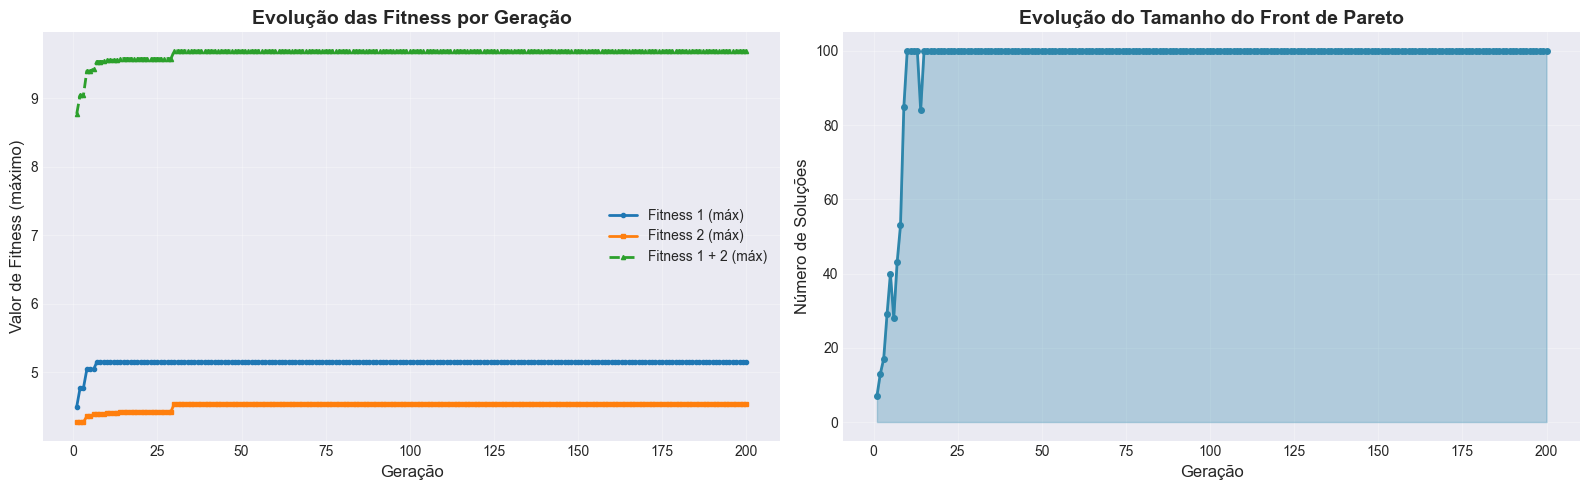


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 200/200 [00:58<00:00,  3.45it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 5


In [8]:
df_pareto_my, _, _  = run_my_nsga2(config, df_predicted)
df_pareto_ua_sa     = run_my_uasa_nsga2(config, df_landscape1)

### Problema 1. Landscape Real

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 10,344 pontos.
Isso representa 1.0344% do espaço de busca.


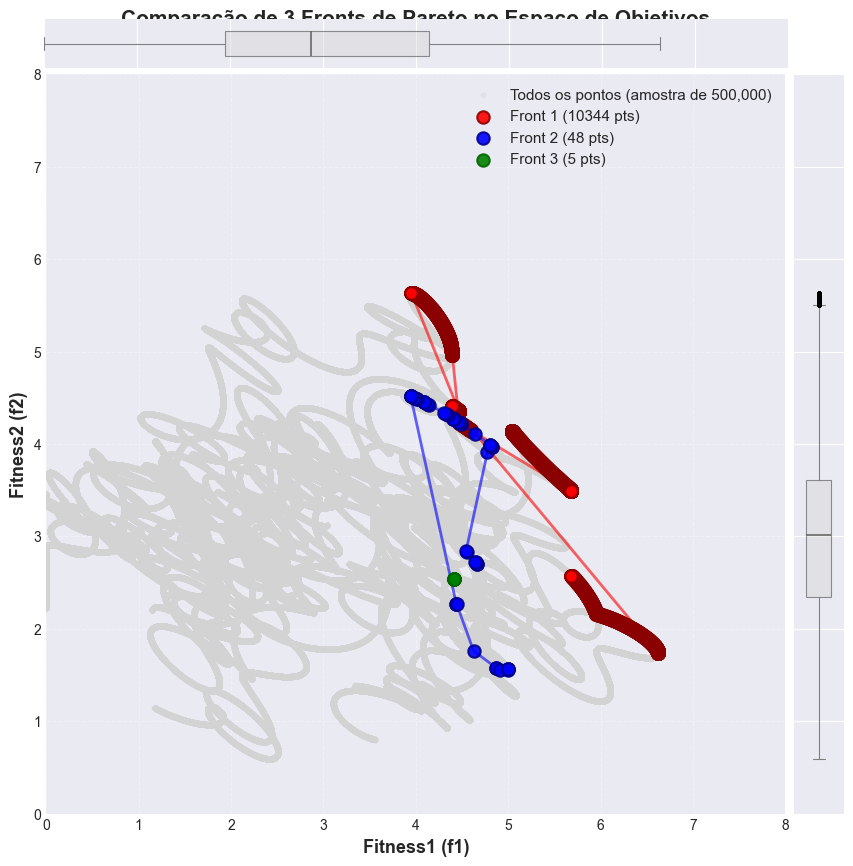

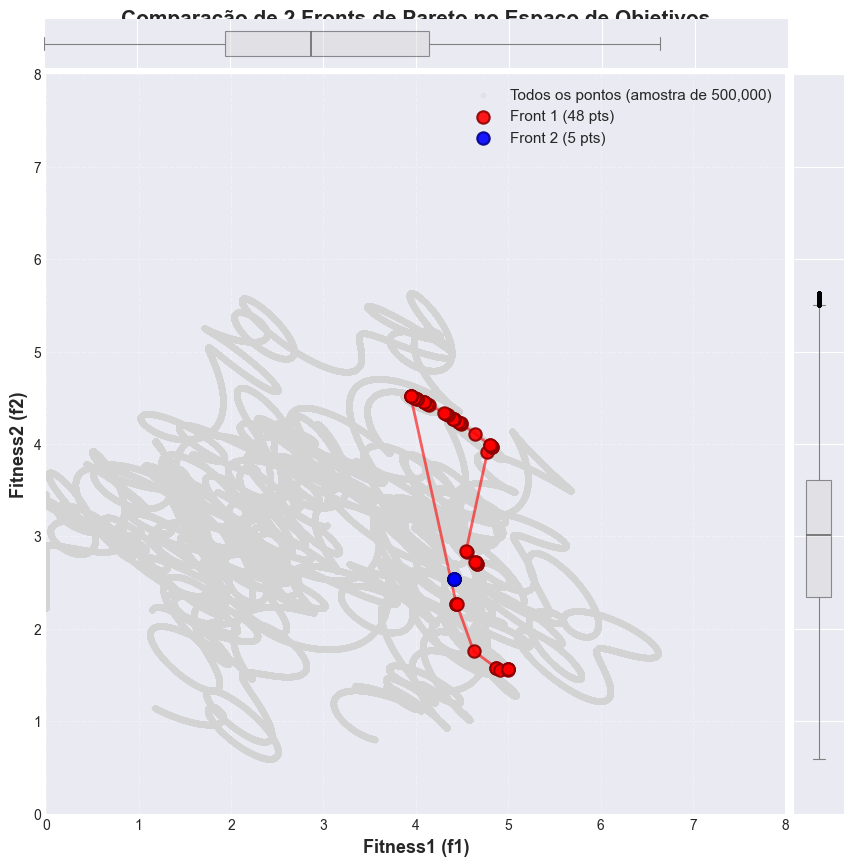

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 48
   • Pontos no front encontrado: 5

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.264958
   • Desvio Padrão:            0.000072

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.264857
   • Máxima:                   0.265060
   • Mediana:                  0.264958

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


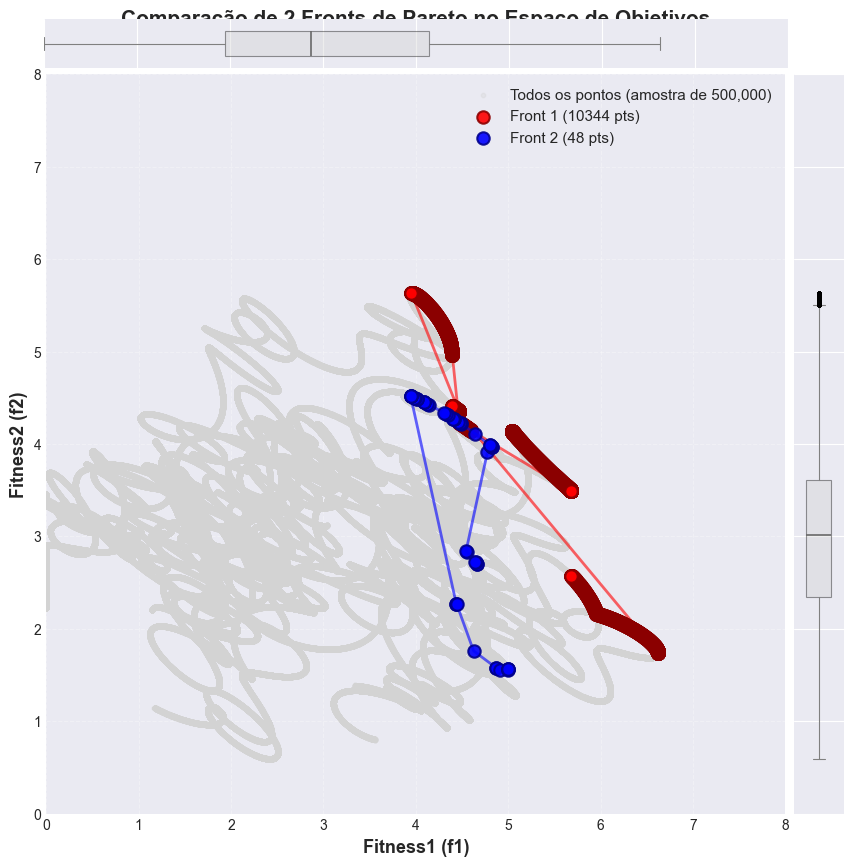

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 10,344
   • Pontos no front encontrado: 48

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.564484
   • Desvio Padrão:            0.467100

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   1.333280
   • Mediana:                  0.391553

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


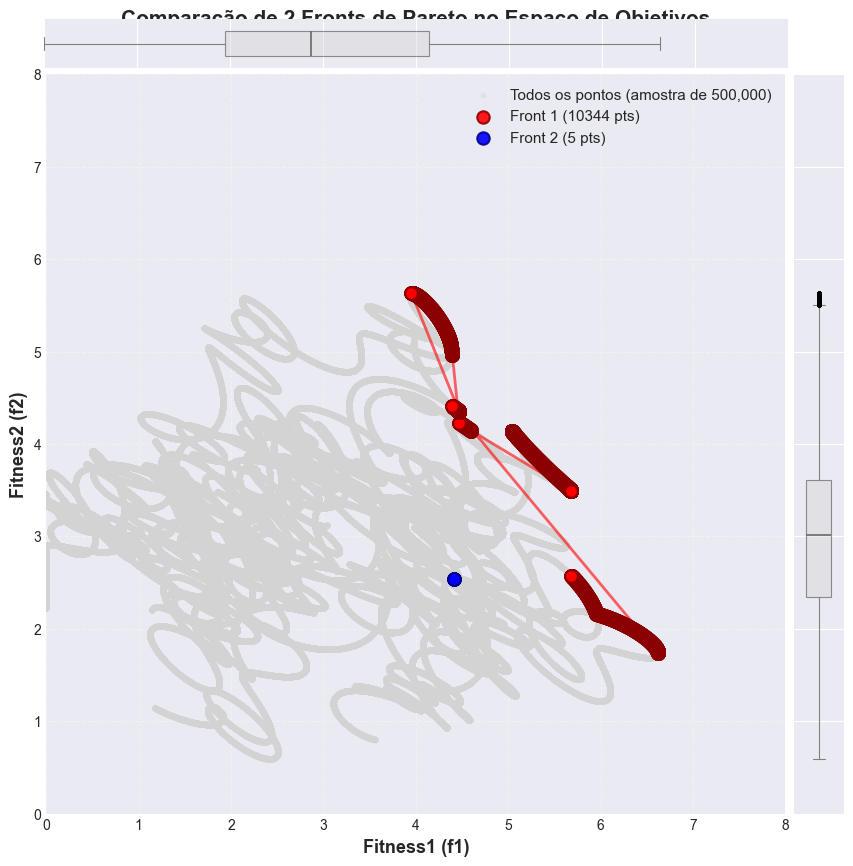

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 10,344
   • Pontos no front encontrado: 5

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        1.266119
   • Desvio Padrão:            0.000216

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   1.265813
   • Máxima:                   1.266425
   • Mediana:                  1.266119

💡 Interpretação:
   ✅ BOA convergência (1.0 ≤ γ < 5.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [9]:
df_pareto_real      = find_pareto_front(df)

df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]

# convergencia entre resultados
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])
display_pareto_fronts3(df, [df_pareto_my, df_pareto_ua_sa])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_my, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df, [df_pareto_real, df_pareto_ua_sa])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

### Problema 1. Landscape Previsto

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 318 pontos.
Isso representa 0.0318% do espaço de busca.


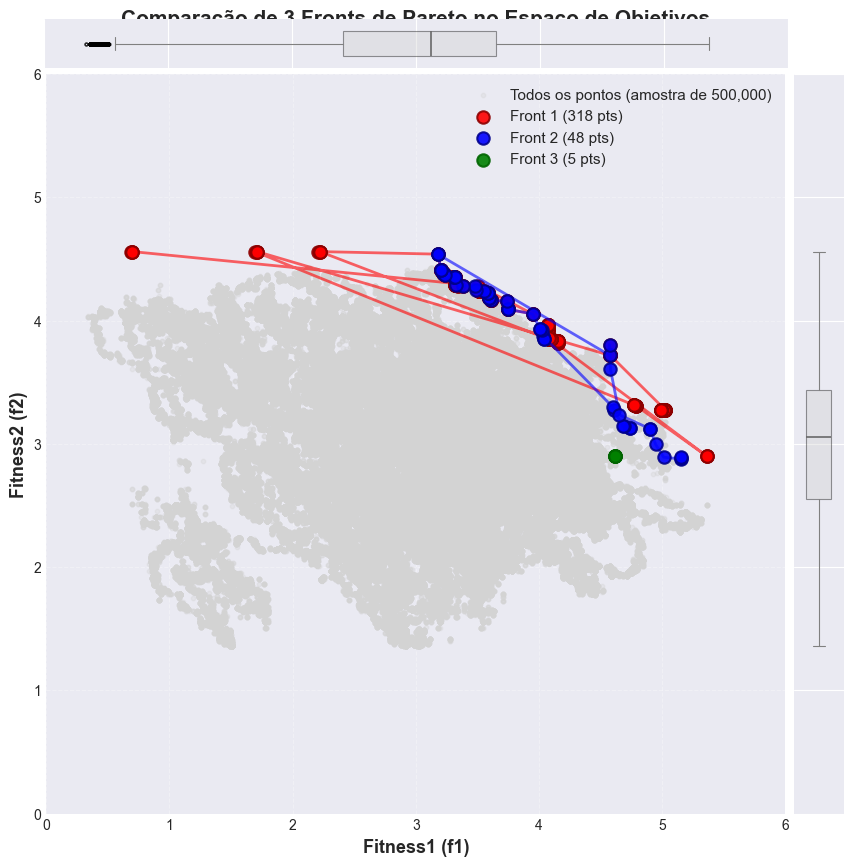

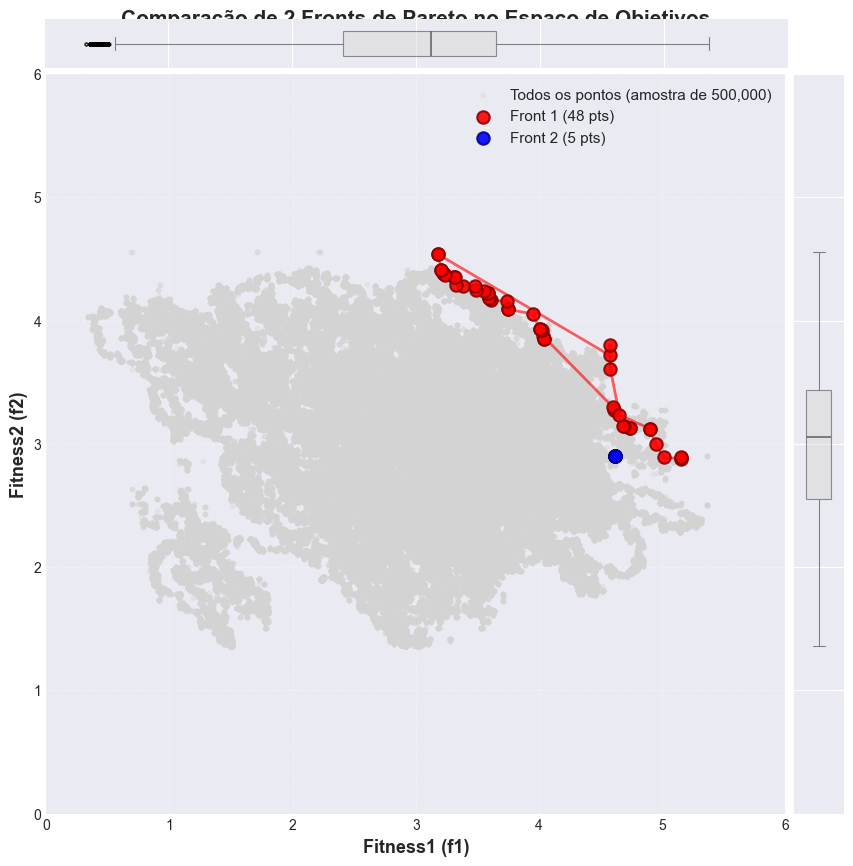

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 48
   • Pontos no front encontrado: 5

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.250177
   • Desvio Padrão:            0.000000

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.250177
   • Máxima:                   0.250177
   • Mediana:                  0.250177

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


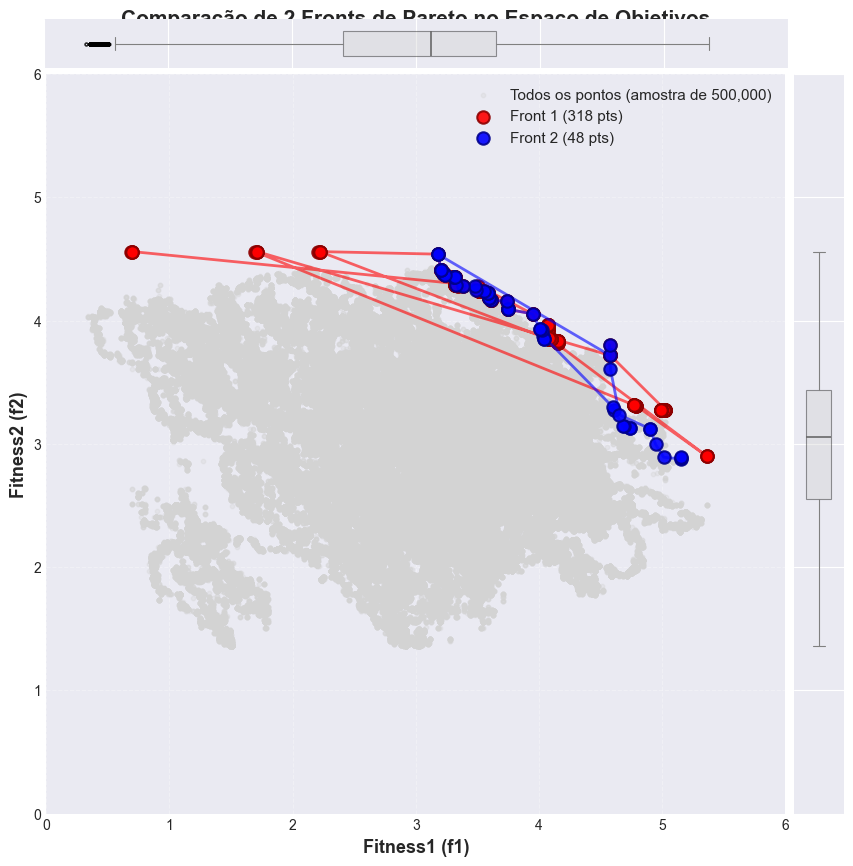

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 318
   • Pontos no front encontrado: 48

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.069236
   • Desvio Padrão:            0.093563

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.349252
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


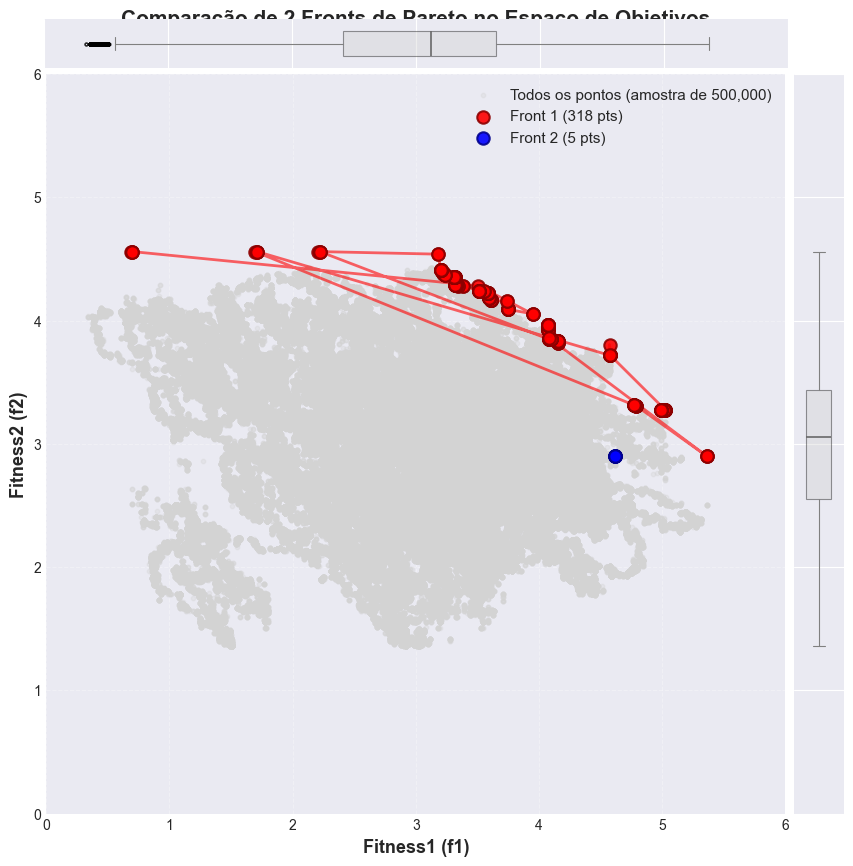

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 318
   • Pontos no front encontrado: 5

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.439822
   • Desvio Padrão:            0.000000

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.439822
   • Máxima:                   0.439822
   • Mediana:                  0.439822

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [10]:
df_pareto_real      = find_pareto_front(df_predicted)

df_pareto_real = df_predicted[df_predicted.registro.isin(df_pareto_real.registro.unique())]
df_pareto_my = df_predicted[df_predicted.registro.isin(df_pareto_my.registro.unique())]
df_pareto_ua_sa = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa.registro.unique())]

# convergencia entre resultados
display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])
display_pareto_fronts3(df_predicted, [df_pareto_my, df_pareto_ua_sa])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_my, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_ua_sa])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

# Problema 2

In [11]:
cols_landscape = ['registro', 'id_simulacao', 'fitness1', 'fitness2']
cols_df = ['registro', 'regiao', 'fitness1_c1', 'fitness2_c1']

df_landscape2 = df2[cols_df].merge(df_mcmc2, on='regiao', how='left')
df_landscape2['fitness1'] = round(df_landscape2['fitness1_c1'] + df_landscape2['erro1_c1'], 3)
df_landscape2['fitness2'] = round(df_landscape2['fitness2_c1'] + df_landscape2['erro2_c1'], 3)
df_landscape2 = df_landscape2[cols_landscape]
df_landscape2 = (df_landscape2
                 .groupby('registro', as_index=False)
                 .agg({
                     'fitness1': list,
                     'fitness2': list
                 }))

df_landscape2

,registro,fitness1,fitness2
0,0,"[15.062, 17.482, 17.379, 14.265, 18.587, 17.68...","[8.023, 13.078, 11.355, 8.069, 12.955, 13.12, ..."
1,1,"[15.062, 17.482, 17.379, 14.265, 18.587, 17.68...","[8.023, 13.078, 11.355, 8.069, 12.955, 13.12, ..."
2,2,"[15.062, 17.482, 17.379, 14.265, 18.587, 17.68...","[8.023, 13.078, 11.355, 8.069, 12.955, 13.12, ..."
3,3,"[15.062, 17.482, 17.379, 14.265, 18.587, 17.68...","[8.023, 13.078, 11.355, 8.069, 12.955, 13.12, ..."
4,4,"[15.062, 17.482, 17.379, 14.265, 18.587, 17.68...","[8.023, 13.078, 11.355, 8.069, 12.955, 13.12, ..."
...,...,...,...
999995,999995,"[7.572, 7.765, 7.71, 7.314, 7.781, 7.429, 7.75...","[12.105, 11.68, 11.51, 10.529, 11.503, 10.811,..."
999996,999996,"[7.572, 7.765, 7.71, 7.314, 7.781, 7.429, 7.75...","[12.105, 11.68, 11.51, 10.529, 11.503, 10.811,..."
999997,999997,"[7.572, 7.765, 7.71, 7.314, 7.781, 7.429, 7.75...","[12.105, 11.68, 11.51, 10.529, 11.503, 10.811,..."
999998,999998,"[7.572, 7.765, 7.71, 7.314, 7.781, 7.429, 7.75...","[12.105, 11.68, 11.51, 10.529, 11.503, 10.811,..."


In [12]:
# experimento
df = df2.copy()
df_predicted = df2.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

100%|██████████| 200/200 [00:15<00:00, 13.13it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 43


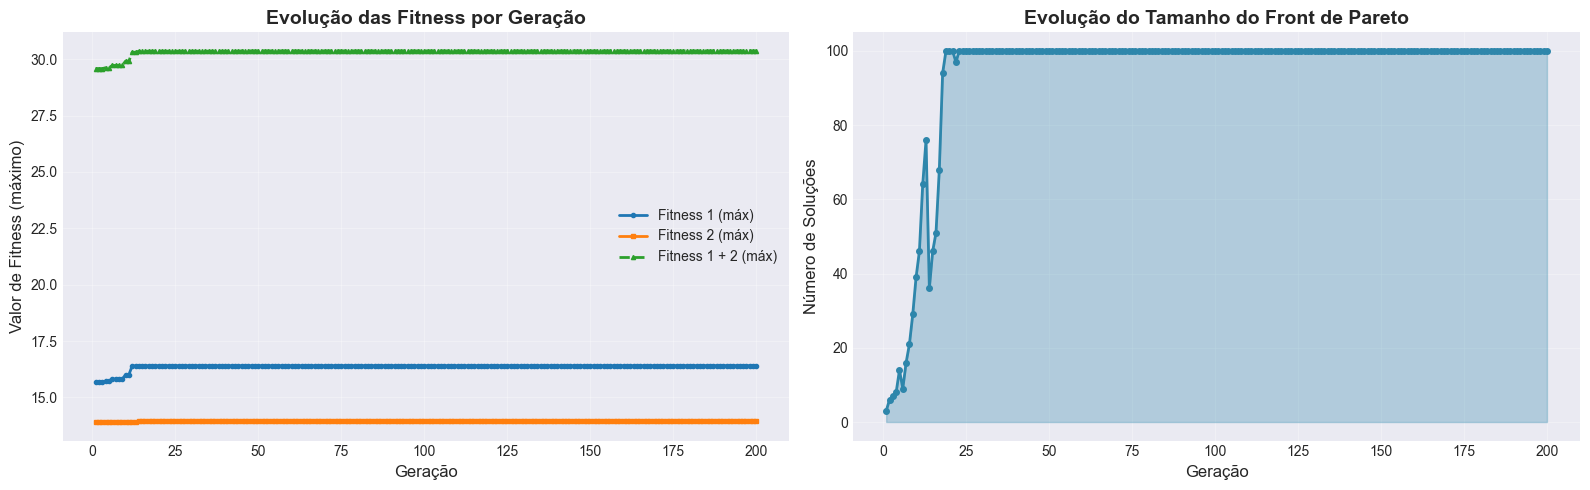


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 200/200 [00:59<00:00,  3.37it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 8


In [13]:
df_pareto_my, _, _  = run_my_nsga2(config, df_predicted)
df_pareto_ua_sa     = run_my_uasa_nsga2(config, df_landscape2)

### Problema 2. Landscape Real

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 4,416 pontos.
Isso representa 0.4416% do espaço de busca.


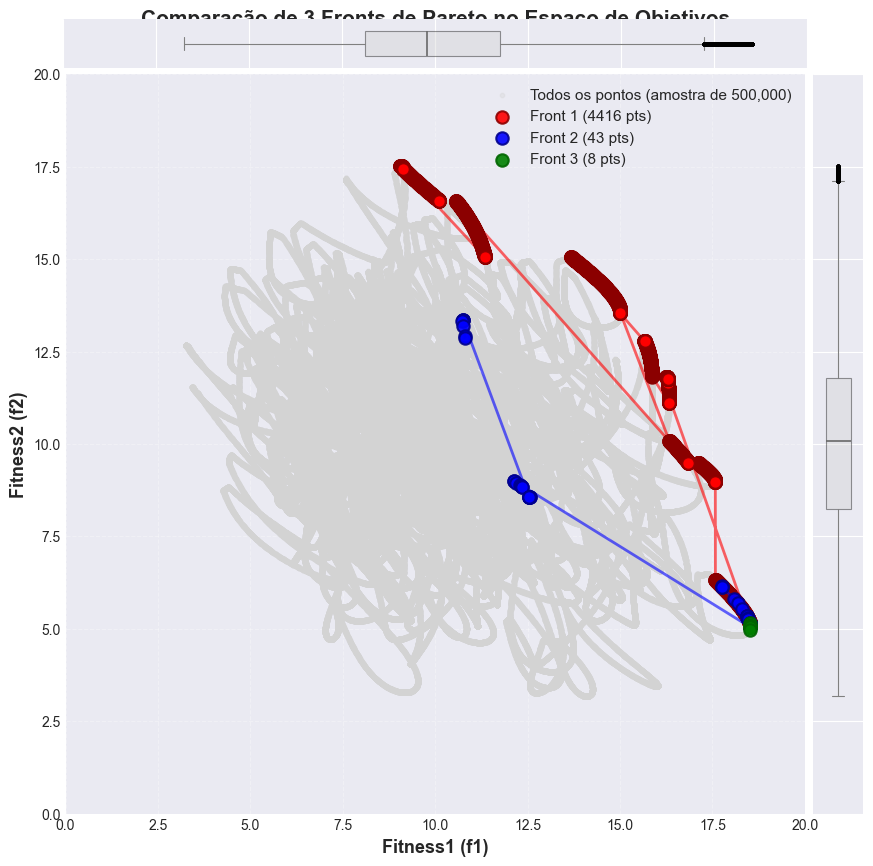

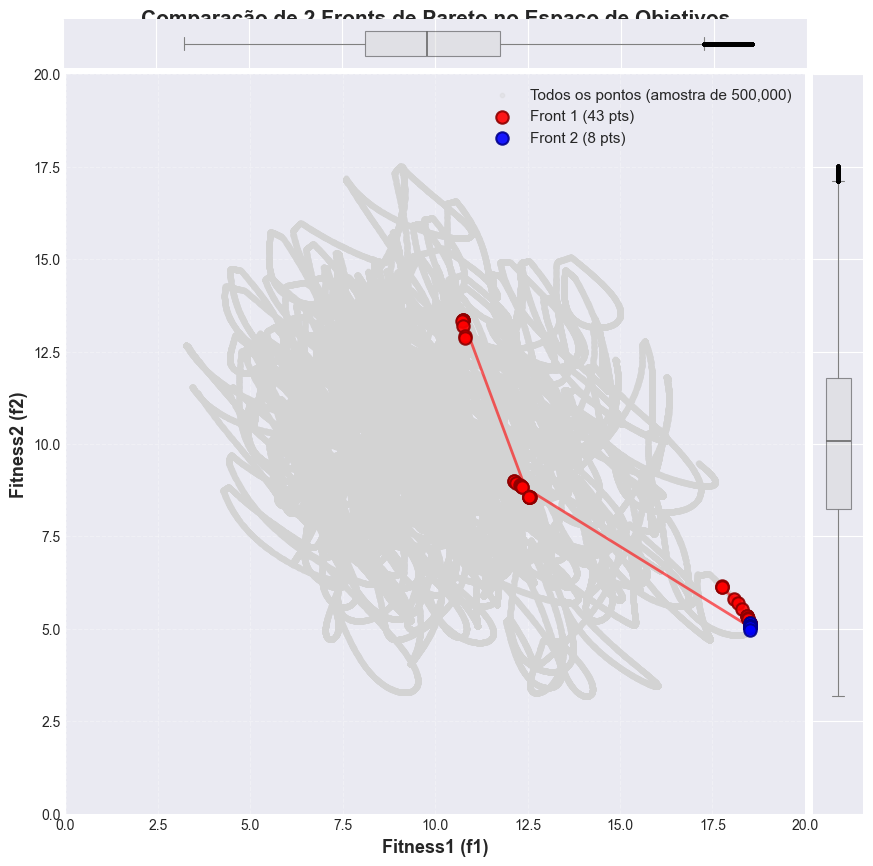

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 43
   • Pontos no front encontrado: 8

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.008541
   • Desvio Padrão:            0.021670

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.065857
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


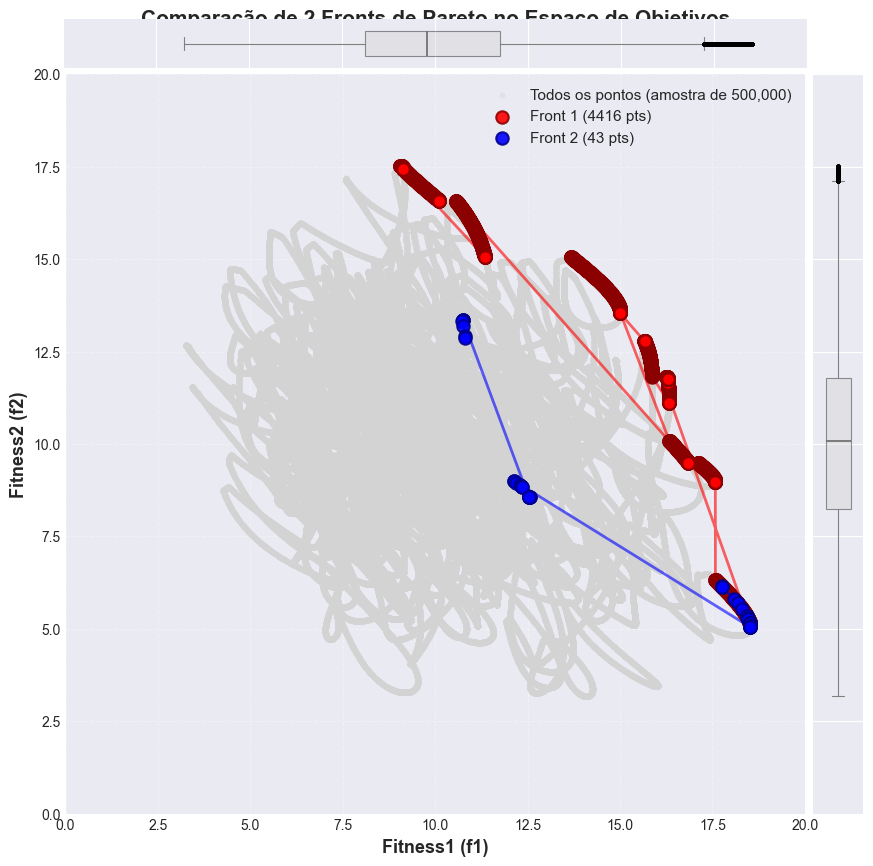

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 4,416
   • Pontos no front encontrado: 43

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        1.673266
   • Desvio Padrão:            1.863336

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   4.330039
   • Mediana:                  0.016134

💡 Interpretação:
   ✅ BOA convergência (1.0 ≤ γ < 5.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


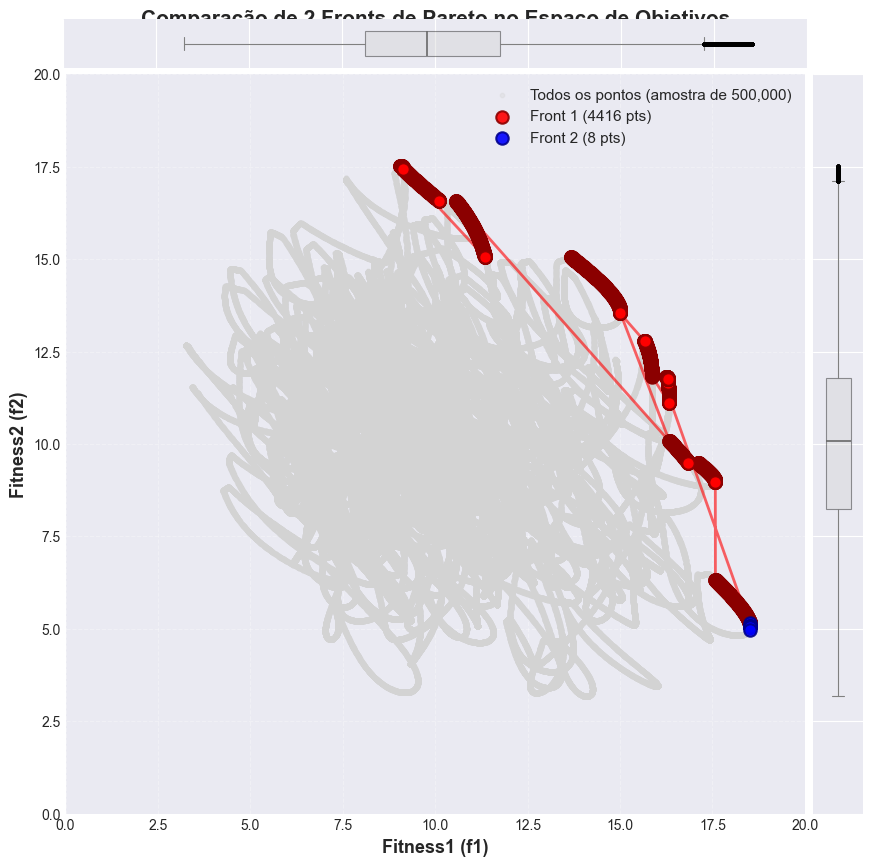

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 4,416
   • Pontos no front encontrado: 8

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.011712
   • Desvio Padrão:            0.026717

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.081790
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [14]:
df_pareto_real      = find_pareto_front(df)

df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]

# convergencia entre resultados
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])
display_pareto_fronts3(df, [df_pareto_my, df_pareto_ua_sa])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_my, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df, [df_pareto_real, df_pareto_ua_sa])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

### Problema 2. Landscape Previsto

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 220 pontos.
Isso representa 0.0220% do espaço de busca.


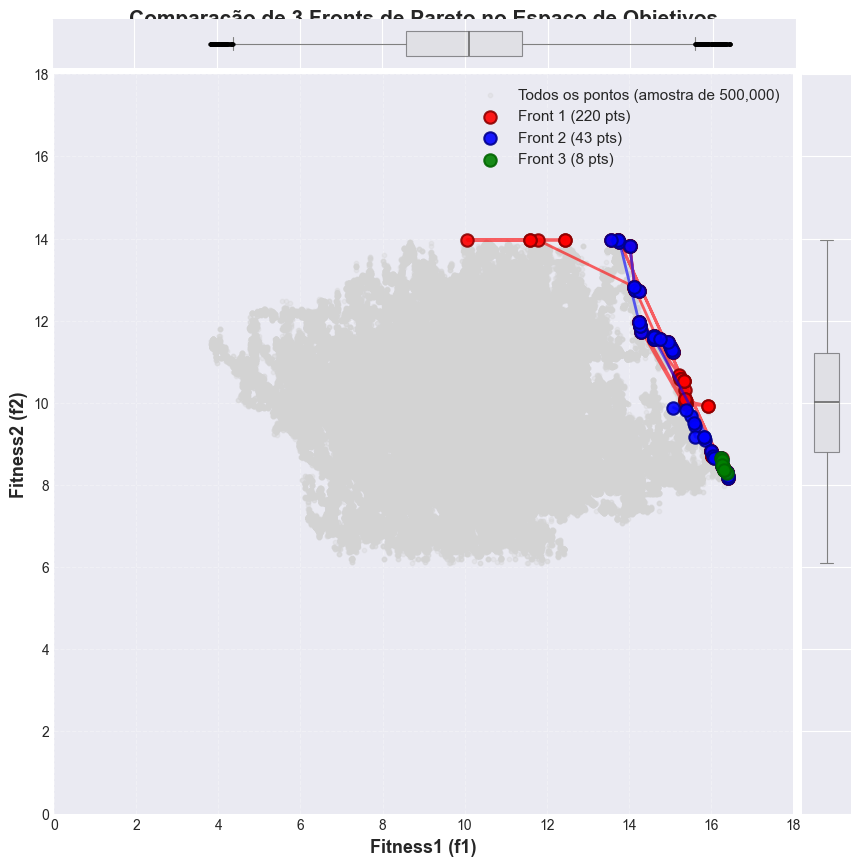

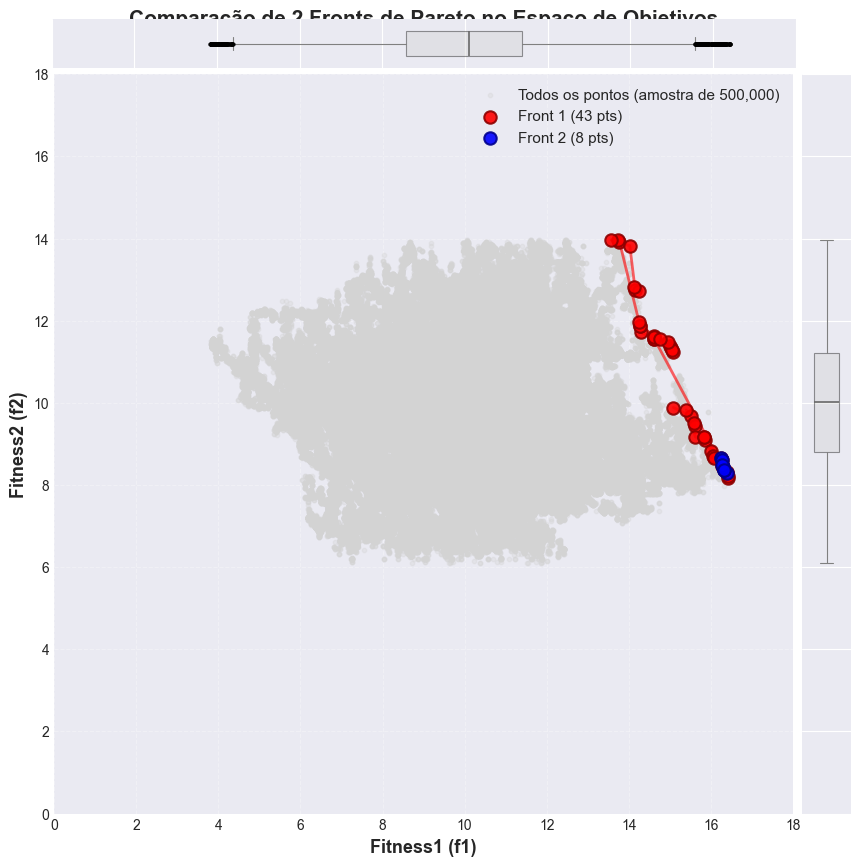

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 43
   • Pontos no front encontrado: 8

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.001800
   • Desvio Padrão:            0.004763

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.014402
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


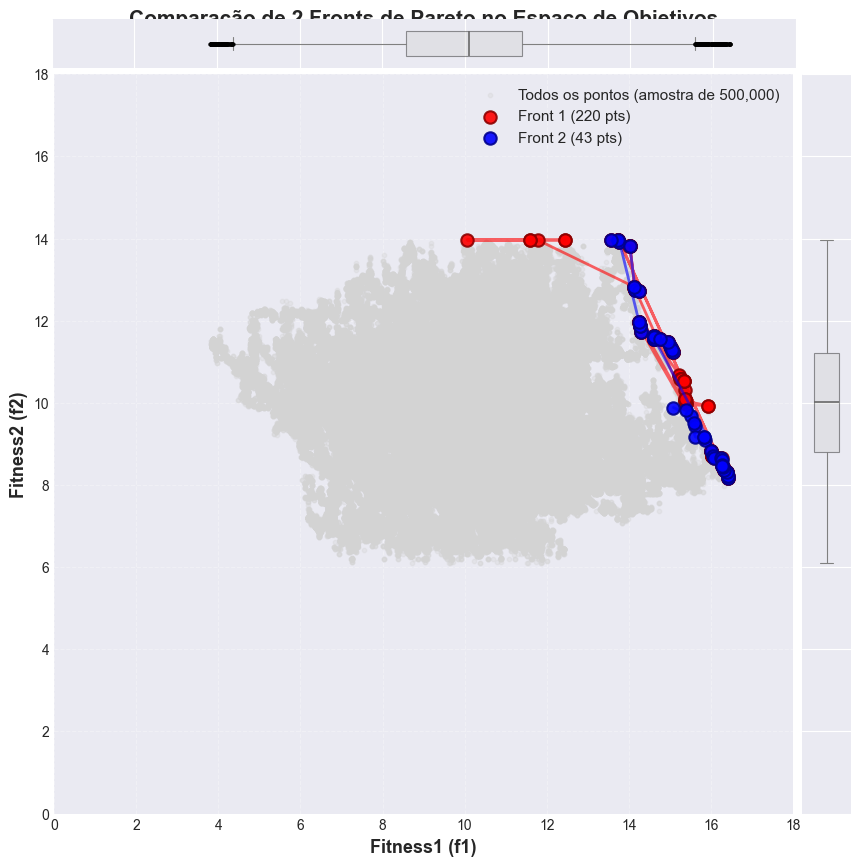

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 220
   • Pontos no front encontrado: 43

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.080941
   • Desvio Padrão:            0.164372

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.555836
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


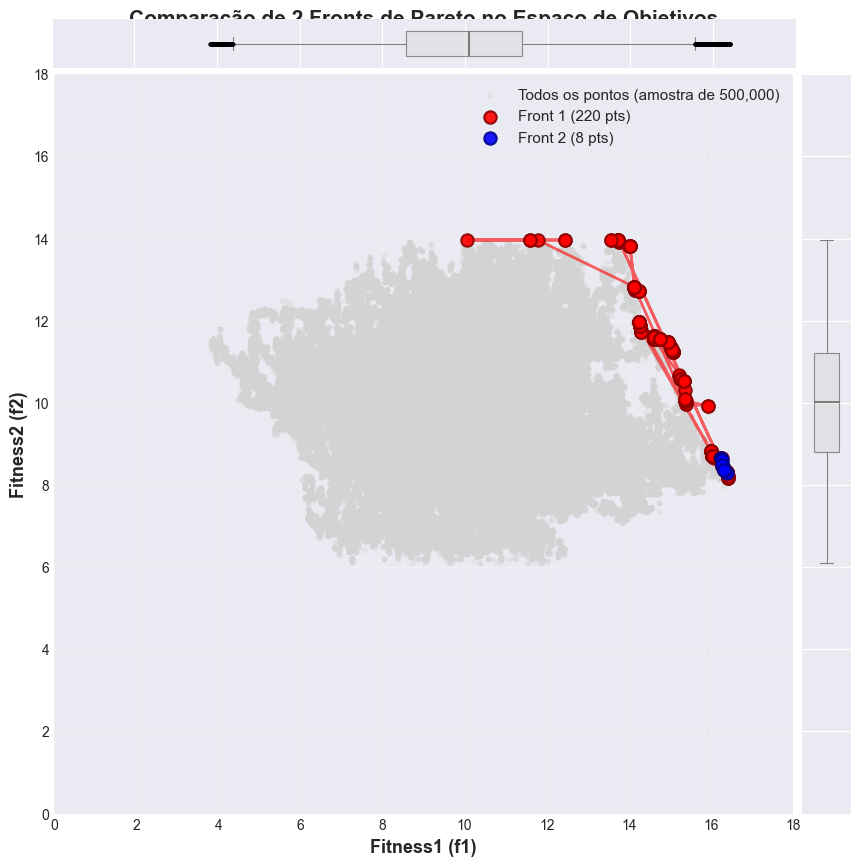

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 220
   • Pontos no front encontrado: 8

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.007152
   • Desvio Padrão:            0.017284

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.052715
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [15]:
df_pareto_real      = find_pareto_front(df_predicted)

df_pareto_real = df_predicted[df_predicted.registro.isin(df_pareto_real.registro.unique())]
df_pareto_my = df_predicted[df_predicted.registro.isin(df_pareto_my.registro.unique())]
df_pareto_ua_sa = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa.registro.unique())]

# convergencia entre resultados
display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])
display_pareto_fronts3(df_predicted, [df_pareto_my, df_pareto_ua_sa])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_my, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_ua_sa])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
print_gamma_metric(gamma_results)